# Prune a recurrent model to preserve its solution to a task.

In [1]:
import numpy as np, kpflow, matplotlib.pyplot as plt, torch, os
from tqdm import tqdm
from torchvision import datasets, transforms

In [41]:
def set_mpl_defaults(fontsize = 13): # Fontsize etc                                                   
    import matplotlib.pyplot as plt                                                                   
    import matplotlib as mpl                                                                          
    plt.rc('font', size=fontsize)          # controls default text sizes                              
    plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title                               
    plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels                            
    plt.rc('xtick', labelsize=fontsize-1)    # fontsize of the tick labels                            
    plt.rc('ytick', labelsize=fontsize-1)    # fontsize of the tick labels                            
    plt.rc('legend', fontsize=fontsize-1)    # legend fontsize                                        
    plt.rc('figure', titlesize=fontsize+1)  # fontsize of the figure title                            
    mpl.rcParams['mathtext.fontset']   = 'cm'        # use Computer Modern                            
    mpl.rcParams['font.family']        = 'serif'     # make non‑math text serif                       
    mpl.rcParams['font.serif']         = 'DejaVu Serif' #'Computer Modern Roman'                      
    mpl.rcParams['pdf.fonttype'] = 42   # TrueType                                                    
    mpl.rcParams['ps.fonttype'] = 42     

set_mpl_defaults(14)

# As a stupid-simple example, train a Resnet on MNIST

In [2]:

# ----- data -----
bs = 200
tfm = transforms.ToTensor()
train = torch.utils.data.DataLoader(datasets.MNIST("./data", train=True, download=True, transform=tfm),
                                    batch_size=bs, shuffle=True)
test  = torch.utils.data.DataLoader(datasets.MNIST("./data", train=False, download=True, transform=tfm),
                                    batch_size=bs)

In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from kpflow.architecture import Model, BasicRNN

# ----- model: width=100, 5 residual hidden layers -----

T = 11


# ----- train -----
dev = "cuda" if torch.cuda.is_available() else "cpu"
dev = "cpu"
# model = ResMLP(width=128, depth=5).to(dev)
model = Model(28*28, 256, 10, rnn = BasicRNN, bias = False).to(dev)

def process_inps(x, y):
    x, y = x.to(dev).float(), y.to(dev)
    x = x.reshape((x.shape[0], -1))
    return torch.stack(T * [x], 1), y


if os.path.exists('model.pt'):
    model.load_state_dict(torch.load('model.pt', weights_only=True))
else:
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)

    pbar = tqdm(range(5))
    for epoch in pbar:
        model.train()
        for x, y in train:
            x, y = process_inps(x, y)
            optim.zero_grad()
            loss = F.cross_entropy(model(x)[0][:, -1], y)
            loss.backward()
            optim.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test:
                x, y = process_inps(x, y)
                pred = model(x)[0][:, -1].argmax(-1)
                correct += (pred == y).sum().item()
                total += y.numel()
        pbar.set_description(f"epoch {epoch+1}: acc={correct/total:.4f}")

    torch.save(model.state_dict(), 'model.pt')

# Operator relevant imports and pruning of the weights

In [4]:
from kpflow.parameter_op import ParameterOperator as Kop
from kpflow.frechet_op import FrechetOperator as PopInv
from kpflow.propagation_op import PropagationOperator_LinearForm as Pop
from kpflow.grad_op import HiddenNTKOperator as NTK
from kpflow.architecture import get_cell_from_model
from kpflow.op_common import IdentityOperator as Id, MatrixWrapper as Mat

In [5]:
inps, targs = next(iter(test))
inps, targs = process_inps(inps, targs)
cell = get_cell_from_model(model).to('cpu')
cell.weight_hh.requires_grad = False
hidd = model(inps)[1]
jop = Kop(cell, inps, hidd).jtheta_op
frop = PopInv(cell, inps, hidd)
pop = Pop(cell, inps, hidd)
jop.vectorize = True # convert params to vector
fischop = jop.T @ pop.T @ pop @ jop
ntk_op = pop @ jop @ jop.T @ pop.T

### Verify that we can replace the explicit one-step parameter operator with an explicit matrix, which we can figure out from the architecture. 

In [48]:
bipart = lambda x : x.reshape((-1, x.shape[-1]))

n, n_in = hidd.shape[-1], inps.shape[-1]

print("state size, params", jop.T.shapes)
print("param count = n * n_in + n * n, check: ", n * n_in + n * n)
print("parameters: ", jop.params.keys())

# X.T shape (n_in, B*T), W_in shape (n, n_in), hidden shape (B*T, n)
X = bipart(inps) 
H = bipart(hidd)
M = torch.cat((X, H), 1) # For input weights and hidden weights, respectively.

j_guess = Mat(X).tprod(Id(n))
print(j_guess.shapes)
j_guess = j_guess.T.reverse_output().T
print(j_guess.shapes)

K_guess = Mat(X @ X.T).tprod(Id(n))
print((j_guess @ j_guess.T).shapes, K_guess.shapes)
print((j_guess @ j_guess.T).compare(K_guess))

kop = Kop(cell, inps, hidd).like(K_guess)
print(K_guess.compare(kop))
print((j_guess @ j_guess.T).like(jop @ jop.T).compare(jop @ jop.T))
print(j_guess.like(jop).compare(jop))

state size, params ((200, 11, 256), (200704,))
param count = n * n_in + n * n, check:  266240
parameters:  dict_keys(['weight_ih'])
((784, 256), (2200, 256))
((256, 784), (2200, 256))
((2200, 256), (2200, 256)) ((2200, 256), (2200, 256))
tensor(0.0958) tensor(1194175.7500) tensor(1234605.5000)
tensor(7.7572e-08)
tensor(0.0970) tensor(1192646.2500) tensor(1248639.2500)
tensor(7.7669e-08)
0.0 tensor(1214177.8750) tensor(1171582.5000)
tensor(0.)
0.0 tensor(6651.3779) tensor(6733.9351)
tensor(0.)


# My guess for jop was correct. 
### It has the form $X \otimes I_n$ for the input weights. We can thus replace that operator by this simple matrix and compute its pseudoinverse explicitly. From that, the full Fischer inverse can be made. 

In [7]:
j_guess = Mat(X).tprod(Id(n))
j_guess = j_guess.T.reverse_output().T
print(j_guess.T.like(jop.T).compare(jop.T))

j_pinv = Mat(torch.linalg.pinv(X)).tprod(Id(n)).reverse_output() #.T.reverse_output().T

rand_inp = torch.rand(j_pinv.shape_in)
print('Pseudo inverse check: ', (j_pinv @ j_guess @ j_pinv).compare(j_pinv))

#j_pinv = j_pinv.reshape(frop.shape_out, j_pinv.shape_in) # [in, out] = [(batches, time, n), (n, n_in)]
frop = frop.reshape(j_pinv.shape_in, j_pinv.shape_in)
fish_pinv = j_pinv @ frop @ frop.T @ j_pinv.T

0.0 tensor(6729.0845) tensor(6593.0273)
tensor(0.)
tensor(9.1782e-05) tensor(41.1217) tensor(41.0796)
Pseudo inverse check:  tensor(2.2320e-06)


In [8]:
print(j_pinv.shape_out, j_pinv.shape_in, frop.shape_out, frop.shape_in, frop.shape_in, frop.shape_out, j_pinv.shape_in, j_pinv.shape_out)

(256, 784) (2200, 256) (2200, 256) (2200, 256) (2200, 256) (2200, 256) (2200, 256) (256, 784)


In [9]:
fish_pinv(torch.rand(fish_pinv.shape_in)).shape

torch.Size([256, 784])

### Now that we have Fischer inverse, do an eigen-decomp to figure out the dominant mode, which corresponds to the smallest mode (weight direction) of the actual Fischer matrix. 

In [11]:
svs, svecs = fish_pinv.svd(5, compute_vecs = True, grammian = False)

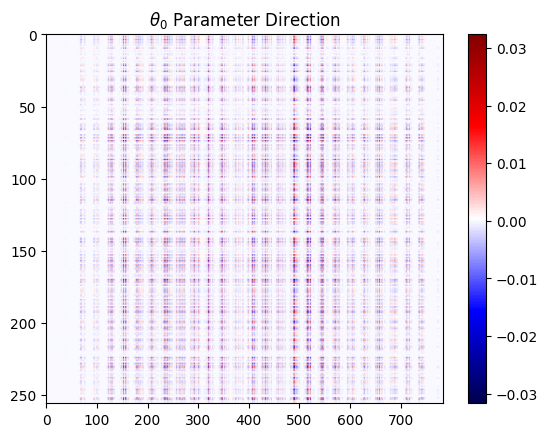

In [28]:
theta_0 = svecs[0].astype(float)
plt.imshow(theta_0, aspect= 'auto', cmap = 'seismic')
plt.colorbar()
plt.title('$\\theta_0$ Parameter Direction')
plt.show()

# Now, hypothetically speaking, perturbations in the $\theta_0$ direction should have basically no effect on state. 
### We verify this by comparing to perturbing in a random parameter direction

Norm of theta_0 is 1 check:  1.0000000000000002


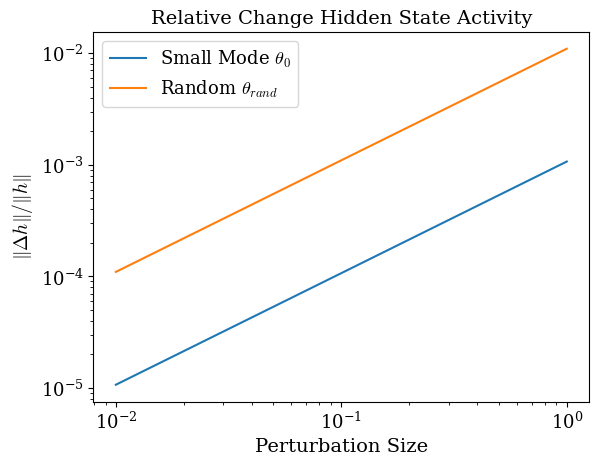

In [47]:

hidd0 = model(inps)[1]

print("Norm of theta_0 is 1 check: ", np.linalg.norm(theta_0))

rand_theta = np.random.randn(*theta_0.shape)
rand_theta /= np.linalg.norm(rand_theta)

step = .1
model_perb = Model(28*28, 256, 10, rnn = BasicRNN, bias = False).to(dev)

steps = 10**np.linspace(-2., 0., 10)
rel_errs_theta_0 = []
rel_errs_rand_theta = []
for step in steps:
    for theta, rel_errs in zip([theta_0, rand_theta], [rel_errs_theta_0, rel_errs_rand_theta]):
        model_perb.load_state_dict(model.state_dict())
        model_perb.rnn.weight_ih_l0.data += torch.from_numpy(theta) * step
        hidd_perb = model_perb(inps)[1]
        rel_errs.append((torch.linalg.norm(hidd0 - hidd_perb) / torch.linalg.norm(hidd0)).item())

plt.loglog(steps, rel_errs_theta_0)
plt.loglog(steps, rel_errs_rand_theta)
plt.title('Relative Change Hidden State Activity')
plt.ylabel('$\|\Delta h\| / \|h\|$')
plt.xlabel('Perturbation Size')
plt.legend(['Small Mode $\\theta_0$', 'Random $\\theta_{rand}$'])
plt.show()
